In [40]:
import os, re, glob
import pandas as pd
import numpy as np

# find all train_log_* dirs excluding "multi"
log_dirs = [d for d in glob.glob("train_log_*") 
            if os.path.isdir(d) and "multi" not in d]
pattern = re.compile(r"train_log_r(\d+)_hc(\d+)_fr(\d+)")

experiments = []
for d in log_dirs:
    m = pattern.match(os.path.basename(d))
    if not m: 
        continue
    r, hc, fr = map(int, m.groups())
    # Substitute fr values: 5 -> 0.5, 75 -> 0.75
    if fr == 5:
        fr = 0.5
    elif fr == 75:
        fr = 0.75
    csv_path = os.path.join(d, "loss_log.csv")
    if not os.path.exists(csv_path):
        continue
    df = pd.read_csv(csv_path)
    # assume there's a "loss" column (and maybe others)
    df['r']     = r
    df['hc']    = hc
    df['fr']    = fr
    df['epoch'] = np.arange(1, len(df) + 1)
    experiments.append(df)

# concatenate
data = pd.concat(experiments, ignore_index=True)
print(f"Loaded {len(experiments)} experiments → {len(data)} total rows")
print("Columns:", data.columns.tolist())
data.head()

Loaded 27 experiments → 270000 total rows
Columns: ['step', 'loss', 'moving_avg', 'r', 'hc', 'fr', 'epoch']


,step,loss,moving_avg,r,hc,fr,epoch
0,0,0.187457,0.187457,64,128,1.0,1
1,1,0.156346,0.171902,64,128,1.0,2
2,2,0.147903,0.163902,64,128,1.0,3
3,3,0.142118,0.158456,64,128,1.0,4
4,4,0.135439,0.153853,64,128,1.0,5


In [41]:
import numpy as np

summary = (
    data
    .groupby(['r','hc','fr'])
    .agg(
        final_loss=('loss',  lambda x: x.iloc[-1]),
        min_loss=('loss',    'min'),
        auc_loss=('loss',    lambda x: np.trapz(x, dx=1.0)),
        slope_loss=('loss',  lambda x: np.polyfit(np.arange(len(x)), x, 1)[0])
    )
    .reset_index()
)
summary.head()

/var/folders/mv/5tl9cp413j5g81sk3wjffnxw0000gn/T/ipykernel_67622/1709063651.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_loss=('loss',    lambda x: np.trapz(x, dx=1.0)),


,r,hc,fr,final_loss,min_loss,auc_loss,slope_loss
0,32,32,0.50,0.002854,0.002497,96.327187,-0.000003
1,32,32,0.75,0.011151,0.009549,242.612045,-0.000005
2,32,32,1.00,0.001232,0.001232,110.141193,-0.000005
3,32,64,0.50,0.005872,0.004731,177.057136,-0.000005
4,32,64,0.75,0.005937,0.005659,155.141248,-0.000004


In [6]:
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("=== Correlations (Pearson & Spearman) vs final_loss ===")
for var in ['r','hc','fr']:
    pr, pp = pearsonr(summary[var], summary.final_loss)
    sr, sp = spearmanr(summary[var], summary.final_loss)
    print(f" {var}: Pearson r={pr:.3f} (p={pp:.3g}), Spearman r={sr:.3f} (p={sp:.3g})")

print("\n=== ANOVA per factor ===")
for var in ['r','hc','fr']:
    model = smf.ols(f"final_loss ~ C({var})", data=summary).fit()
    anova = sm.stats.anova_lm(model, typ=2)
    print(f"\nANOVA for {var}:\n", anova)

print("\n=== OLS: final_loss ~ r + hc + fr ===")
lm = smf.ols("final_loss ~ r + hc + fr", data=summary).fit()
print(lm.summary())

=== Correlations (Pearson & Spearman) vs final_loss ===
 r: Pearson r=0.682 (p=8.95e-05), Spearman r=0.763 (p=3.71e-06)
 hc: Pearson r=-0.516 (p=0.00583), Spearman r=-0.478 (p=0.0118)
 fr: Pearson r=-0.034 (p=0.867), Spearman r=0.146 (p=0.469)

=== ANOVA per factor ===

ANOVA for r:
             sum_sq    df          F    PR(>F)
C(r)      0.002764   2.0  10.758757  0.000462
Residual  0.003083  24.0        NaN       NaN

ANOVA for hc:
             sum_sq    df         F    PR(>F)
C(hc)     0.001691   2.0  4.880805  0.016652
Residual  0.004157  24.0       NaN       NaN

ANOVA for fr:
             sum_sq    df         F    PR(>F)
C(fr)     0.000012   2.0  0.023798  0.976506
Residual  0.005836  24.0       NaN       NaN

=== OLS: final_loss ~ r + hc + fr ===
                            OLS Regression Results                            
Dep. Variable:             final_loss   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.698

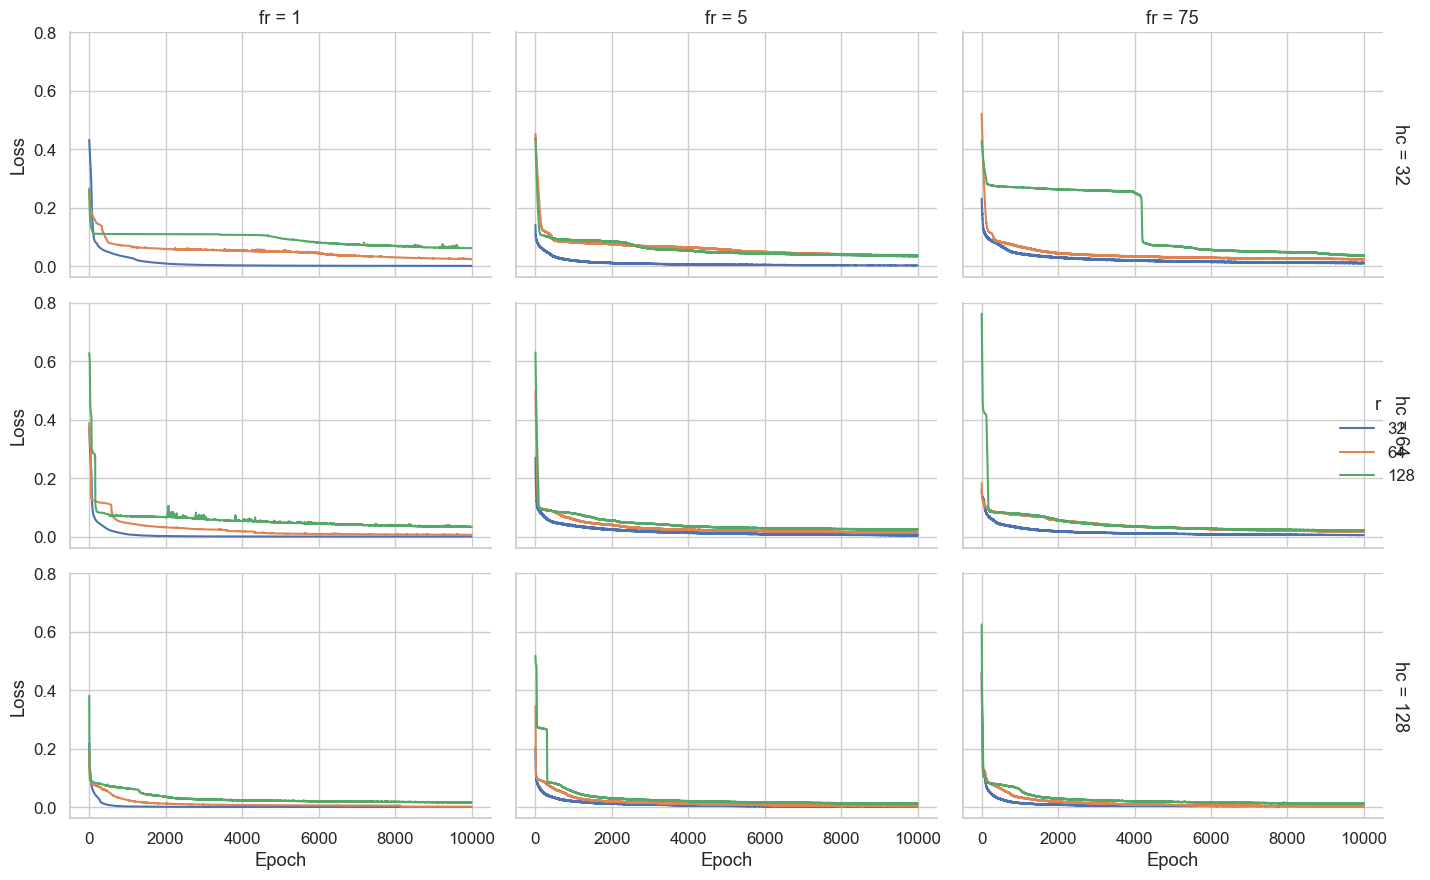

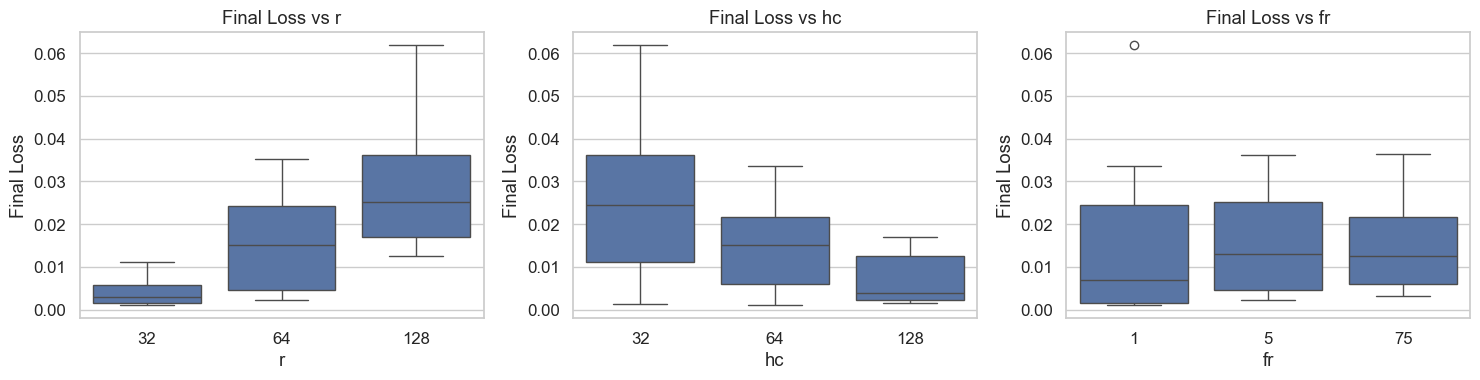

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid', font_scale=1.1)

# 1) Loss-vs-epoch curves, faceted by hc (rows) and fr (cols), hue=r
g = sns.FacetGrid(
    data, row='hc', col='fr', hue='r',
    margin_titles=True, sharey=True,
    height=3, aspect=1.5
)
g.map(sns.lineplot, 'epoch', 'loss')
g.add_legend(title='r')
g.set_axis_labels('Epoch', 'Loss')
plt.tight_layout()
plt.show()

# 2) Boxplots of final_loss vs each hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, ['r','hc','fr']):
    sns.boxplot(x=var, y='final_loss', data=summary, ax=ax)
    ax.set_title(f'Final Loss vs {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Final Loss')
plt.tight_layout()
plt.show()

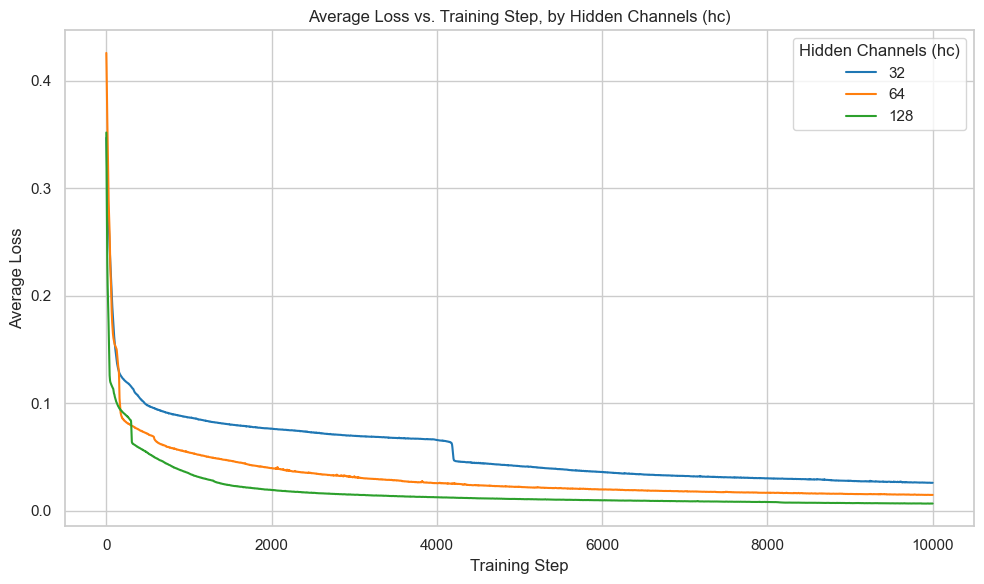

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

df_r32 = data
avg_loss = (
    df_r32
    .groupby(['hc','epoch'])['loss']
    .mean()
    .reset_index()
)

# Add a centered rolling‐mean (window=5) per hidden‐channel
avg_loss['loss_smooth'] = (
    avg_loss
    .groupby('hc')['loss']
    .transform(lambda x: x.rolling(window=5, min_periods=1, center=True).mean())
)

# Plot the smoothed curves
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_loss,
    x='epoch',
    y='loss_smooth',
    hue='hc',
    palette='tab10',
    marker=None
)
plt.title('Average Loss vs. Training Step, by Hidden Channels (hc)')
plt.xlabel('Training Step')
plt.ylabel('Average Loss')
plt.legend(title='Hidden Channels (hc)')
plt.tight_layout()
plt.show()

/var/folders/mv/5tl9cp413j5g81sk3wjffnxw0000gn/T/ipykernel_67622/1487868633.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


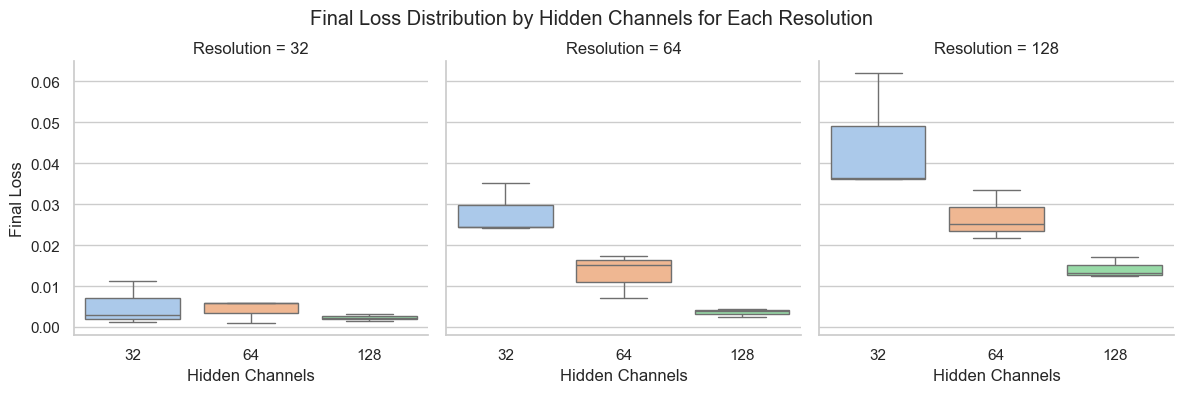

In [ ]:
# + codecell
import matplotlib.pyplot as plt
import seaborn as sns

# Box‐plots of final_loss by hc, faceted by r
g = sns.catplot(
    data=summary,
    x='hc',
    y='final_loss',
    col='r',
    kind='box',
    sharey=True,
    palette='pastel',
    height=4,
    aspect=1
)

# Tweak labels and title
g.set_axis_labels('Hidden Channels', 'Final Loss')
g.set_titles('Resolution = {col_name}')
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Final Loss Distribution by Hidden Channels for Each Resolution')

plt.show()

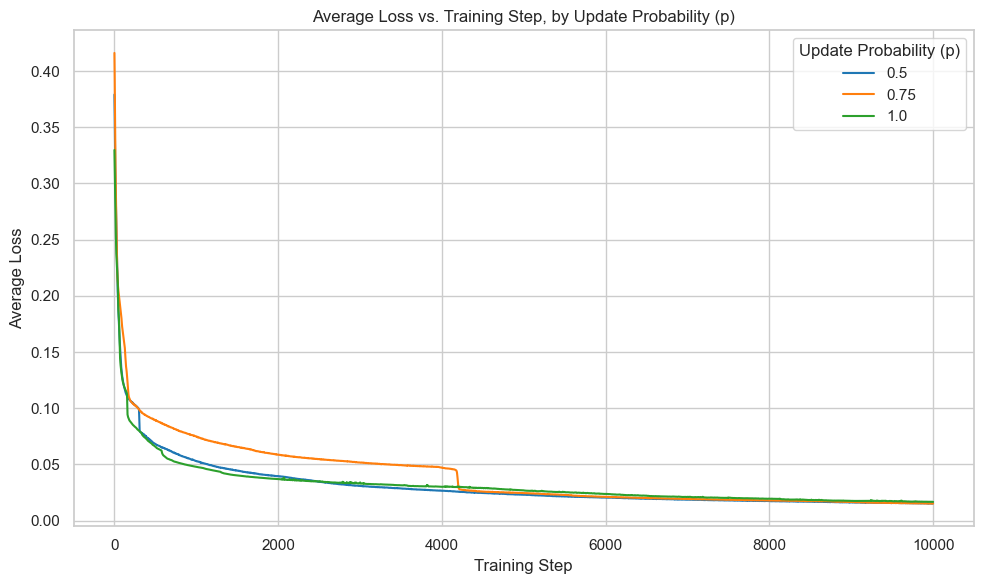

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_r32 = data
avg_loss = (
    df_r32
    .groupby(['fr','epoch'])['loss']
    .mean()
    .reset_index()
)

# Add a centered rolling‐mean (window=5) per hidden‐channel
avg_loss['loss_smooth'] = (
    avg_loss
    .groupby('fr')['loss']
    .transform(lambda x: x.rolling(window=5, min_periods=1, center=True).mean())
)

# Plot the smoothed curves
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_loss,
    x='epoch',
    y='loss_smooth',
    hue='fr',
    palette='tab10',
    marker=None
)
plt.title('Average Loss vs. Training Step, by Update Probability (p)')
plt.xlabel('Training Step')
plt.ylabel('Average Loss')
plt.legend(title='Update Probability (p)')
plt.tight_layout()
plt.show()

/var/folders/mv/5tl9cp413j5g81sk3wjffnxw0000gn/T/ipykernel_67622/1990812937.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


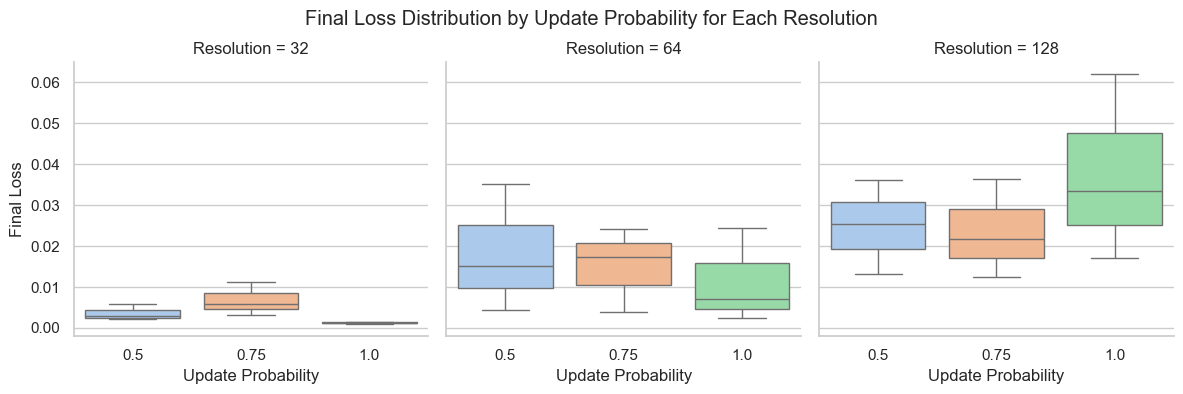

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=summary,
    x='fr',
    y='final_loss',
    col='r',
    kind='box',
    sharey=True,
    palette='pastel',
    height=4,
    aspect=1
)

# Tweak labels and title
g.set_axis_labels('Update Probability', 'Final Loss')
g.set_titles('Resolution = {col_name}')
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Final Loss Distribution by Update Probability for Each Resolution')

plt.show()

In [49]:
# ─── Cell: Load multi3 experiments & compute mean target losses ───
import os, glob, re
import pandas as pd
import numpy as np

# find all train_log_multi3_* dirs
multi3_dirs = [d for d in glob.glob("train_log_multi3*") if os.path.isdir(d)]
pattern = re.compile(r"train_log_multi3_r(\d+)_hc(\d+)_fr(\d+)")

dfs = []
for d in multi3_dirs:
    m = pattern.match(os.path.basename(d))
    if not m:
        continue
    r, hc, fr = map(int, m.groups())
    # map fr back to float
    if fr == 5:
        fr = 0.5
    elif fr == 75:
        fr = 0.75

    csv_path = os.path.join(d, "loss_log.csv")
    df = pd.read_csv(csv_path)
    df["r"]     = r
    df["hc"]    = hc
    df["fr"]    = fr
    # add epoch index (1-based)
    df["epoch"] = np.arange(1, len(df) + 1)
    dfs.append(df)

# concatenate and compute mean target losses per epoch
data_multi3 = pd.concat(dfs, ignore_index=True)
mean_losses = data_multi3.groupby("epoch")[["loss_target_1", "loss_target_2", "loss_target_3"]].mean()

mean_losses.head()

,loss_target_1,loss_target_2,loss_target_3
epoch,,,
1,0.523002,0.849461,0.922854
2,0.497969,0.819600,0.900292
3,0.475326,0.787042,0.874017
4,0.452356,0.758949,0.848499
5,0.432237,0.730943,0.826415


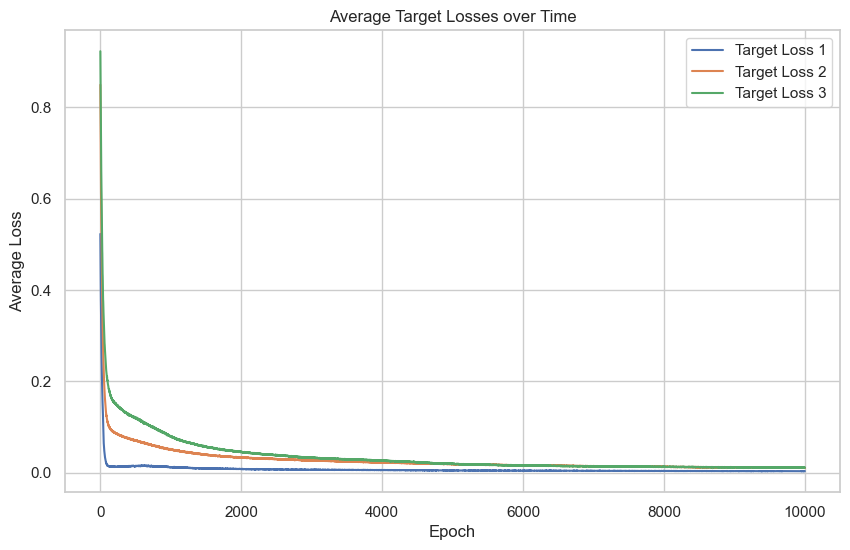

In [51]:
# ─── Cell: Plot average target losses over time ───
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(mean_losses.index, mean_losses["loss_target_1"], label="Target Loss 1")
plt.plot(mean_losses.index, mean_losses["loss_target_2"], label="Target Loss 2")
plt.plot(mean_losses.index, mean_losses["loss_target_3"], label="Target Loss 3")

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Average Target Losses over Time")
plt.legend()
plt.grid(True)
plt.show()